In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv('../lab-eda-univariate/amz_uk_price_prediction_dataset.csv')
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


---

## Part 1

In [ ]:
# Crosstab

crosstab = pd.crosstab(df['category'], df['isBestSeller'])
crosstab['best_seller_rate'] = crosstab[True] / crosstab.sum(axis=1)
crosstab_sorted = crosstab.sort_values(by='best_seller_rate', ascending=False)
crosstab_sorted[['best_seller_rate']].head()

isBestSeller,best_seller_rate
category,
Grocery,0.058135
Smart Home Security & Lighting,0.057692
Health & Personal Care,0.057686
Mobile Phone Accessories,0.042471
Power & Hand Tools,0.035339


In [ ]:
# Chi Squared

chi2, p, dof, expected = chi2_contingency(pd.crosstab(df['category'], df['isBestSeller']))
print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")

Chi2 = 36540.20, p-value = 0.0000


In [ ]:
# Cramér's V

n = crosstab.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))
print(f"Cramér's V = {cramers_v:.3f}")

Cramér's V = 0.086


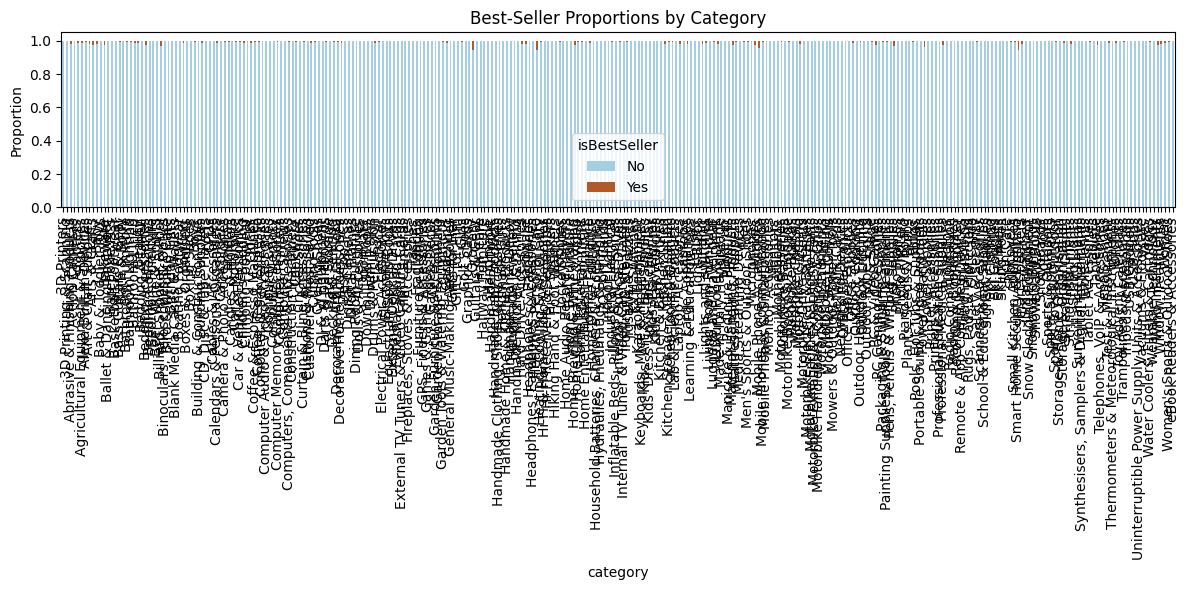

In [ ]:
# Barplots

crosstab_plot = pd.crosstab(df['category'], df['isBestSeller'], normalize='index')
crosstab_plot.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Paired')
plt.ylabel('Proportion')
plt.title('Best-Seller Proportions by Category')
plt.legend(title='isBestSeller', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

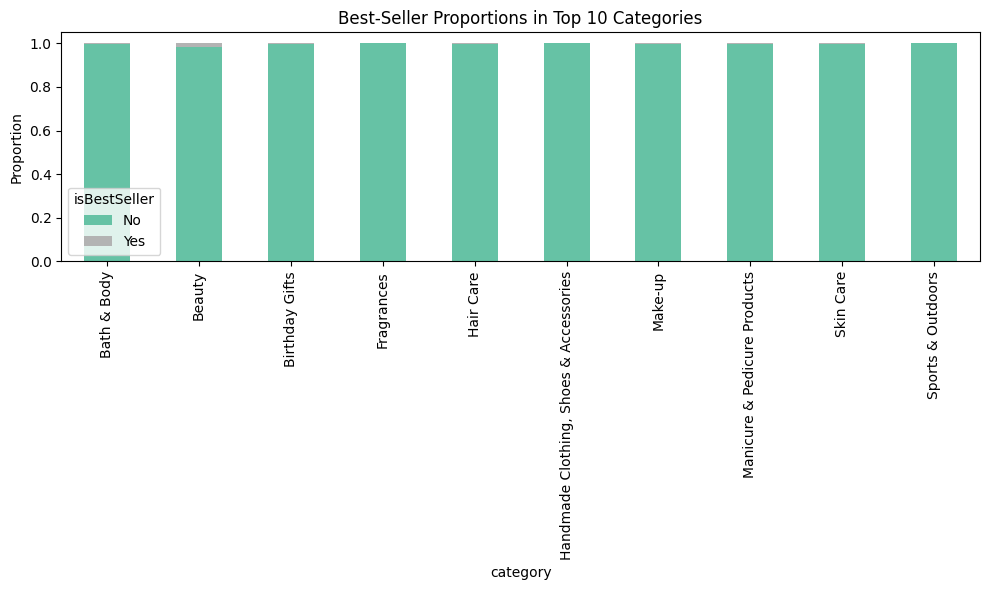

In [14]:
# Since there are too many categories to plot, we will limit them.
# Top 10 categories by total number of listings
top_categories = df['category'].value_counts().head(10).index

# Filter original DataFrame
filtered_df = df[df['category'].isin(top_categories)]

# Plot again
crosstab_plot = pd.crosstab(filtered_df['category'], filtered_df['isBestSeller'], normalize='index')
crosstab_plot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.ylabel('Proportion')
plt.title('Best-Seller Proportions in Top 10 Categories')
plt.legend(title='isBestSeller', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

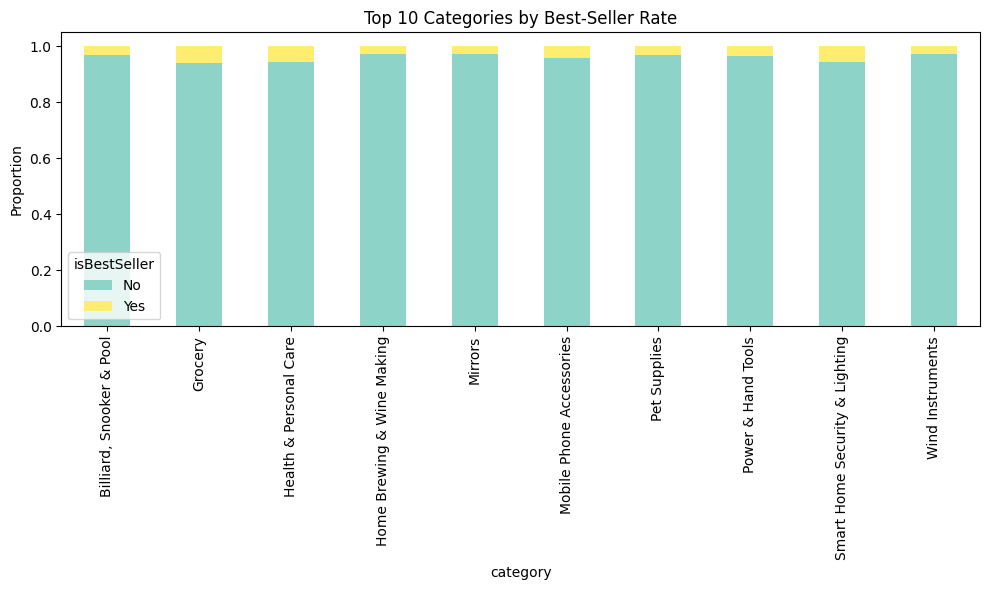

In [ ]:
# Even now you can barely see any proportions, there's one tiny bit you can make out in the 'Beauty' category.
# So we'll try something else: Top Categories by Best-Seller Rate
# Use previous crosstab with 'best_seller_rate'
top_best_seller_cats = crosstab_sorted.head(10).index

filtered_df = df[df['category'].isin(top_best_seller_cats)]

# Plot
crosstab_plot = pd.crosstab(filtered_df['category'], filtered_df['isBestSeller'], normalize='index')
crosstab_plot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set3')
plt.ylabel('Proportion')
plt.title('Top 10 Categories by Best-Seller Rate')
plt.legend(title='isBestSeller', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

---

## Part 2

In [16]:
# Remove Outliers in Product Prices using IQR

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

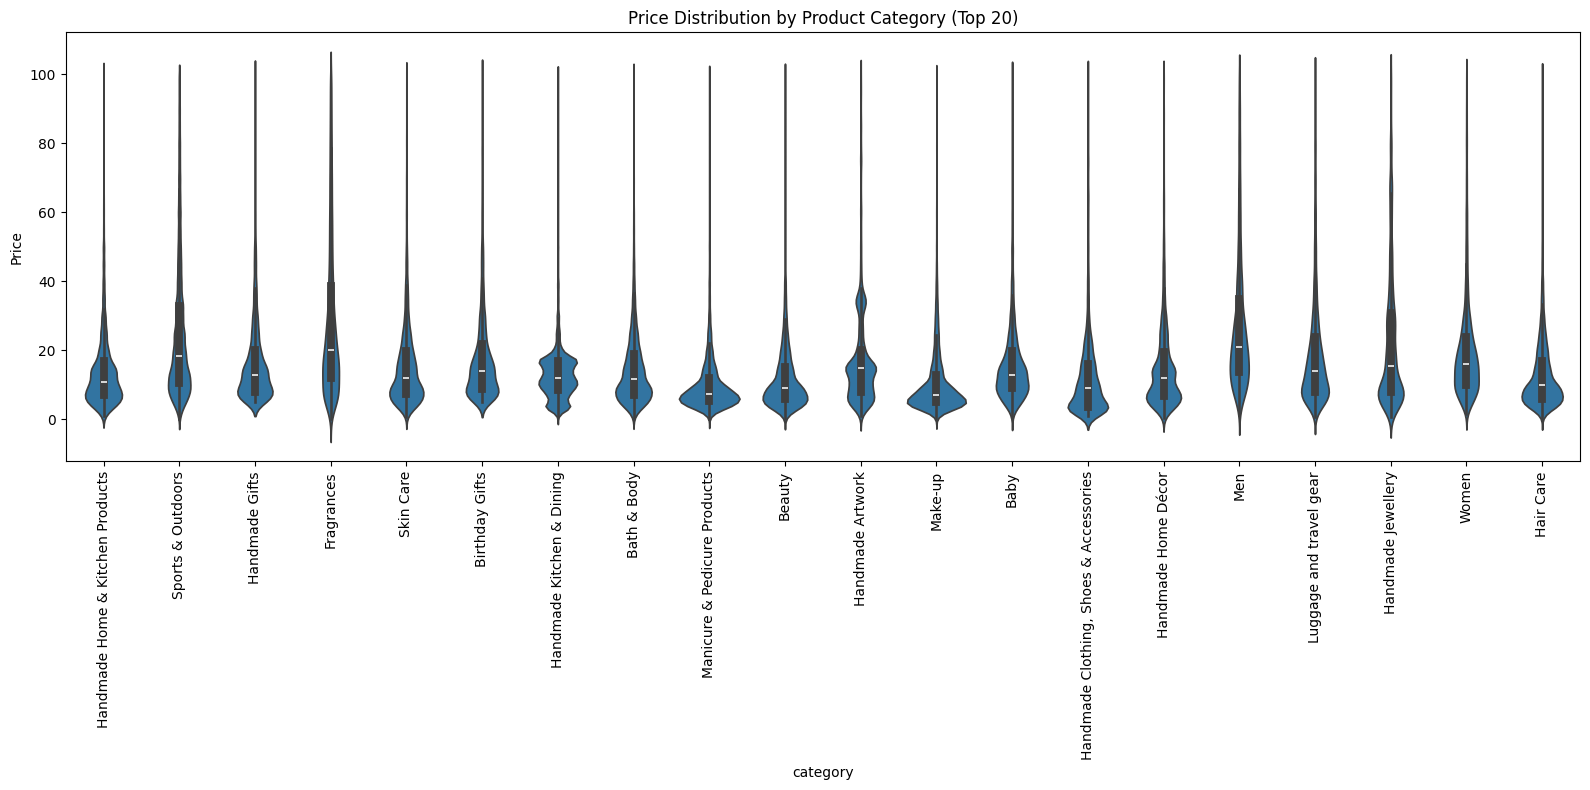

In [17]:
# Violin Plot for Price Across Top 20 Categories (by count)

top_20_categories = df_no_outliers['category'].value_counts().head(20).index
df_top_20 = df_no_outliers[df_no_outliers['category'].isin(top_20_categories)]

plt.figure(figsize=(16, 8))
sns.violinplot(data=df_top_20, x='category', y='price')
plt.xticks(rotation=90)
plt.title('Price Distribution by Product Category (Top 20)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [18]:
# Identify Category with Highest Median Price (No Filter)

median_prices = df_no_outliers.groupby('category')['price'].median().sort_values(ascending=False)
print(median_prices.head(1))

category
Desktop PCs    74.0
Name: price, dtype: float64


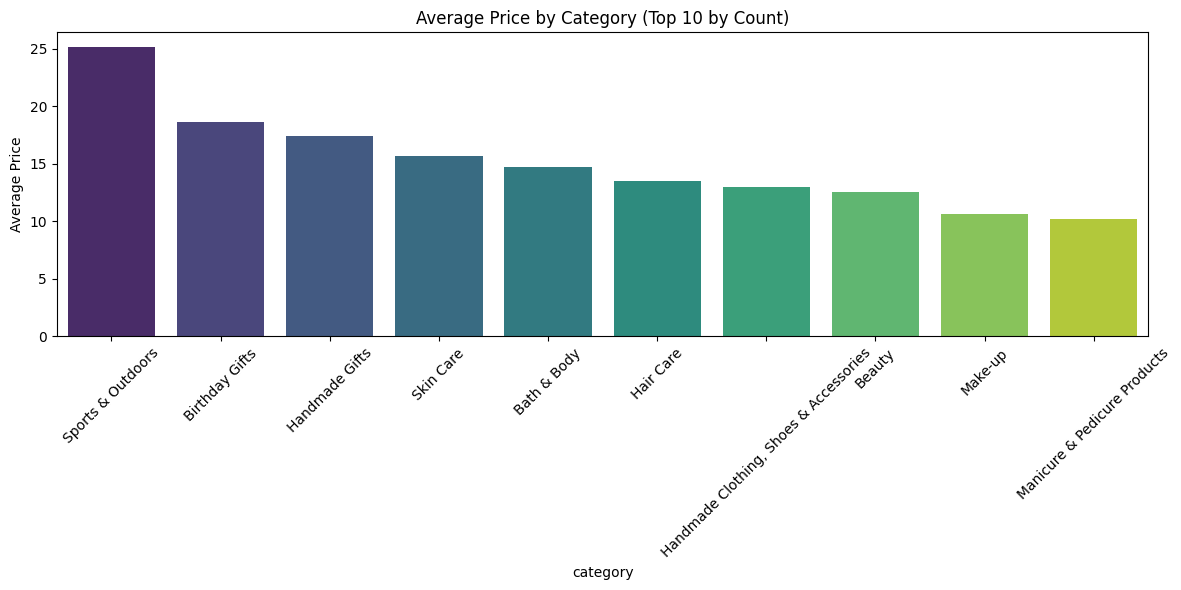

In [20]:
# Bar Chart Comparing Average Prices for Top 10 Categories (by count)

top_10_categories = df_no_outliers['category'].value_counts().head(10).index
df_top_10 = df_no_outliers[df_no_outliers['category'].isin(top_10_categories)]

avg_prices = df_top_10.groupby('category')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_prices.index, y=avg_prices.values, hue=avg_prices.index, palette='viridis', legend=False)
plt.title('Average Price by Category (Top 10 by Count)')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

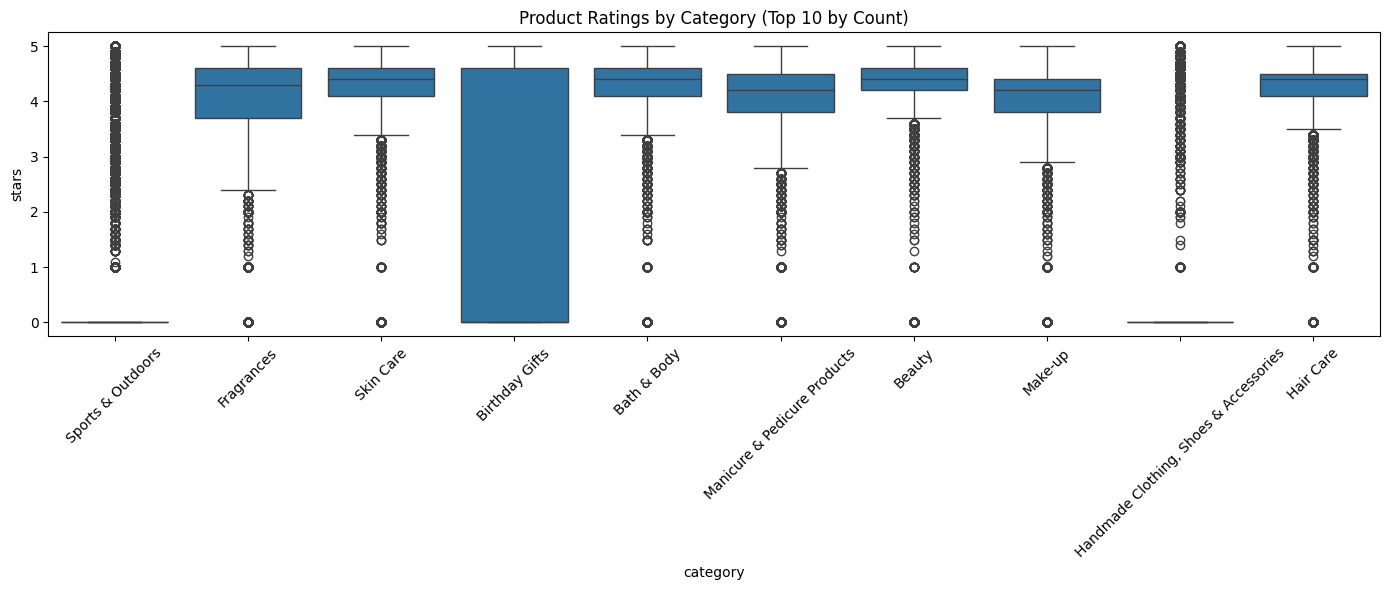

In [22]:
# Box Plot of Ratings by Category (Top 10 by count)

top_10_cat_ratings = df['category'].value_counts().head(10).index
df_ratings = df[df['category'].isin(top_10_cat_ratings)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_ratings, x='category', y='stars')
plt.xticks(rotation=45)
plt.title('Product Ratings by Category (Top 10 by Count)')
plt.tight_layout()
plt.show()

In [24]:
# Category with Highest Median Rating (No Filter)

median_ratings = df.groupby('category')['stars'].median().sort_values(ascending=False)
print(median_ratings.head(1))

category
Computer Memory    4.7
Name: stars, dtype: float64


---

## Part 3

In [27]:
# Correlation Coefficient Between Price and Rating

correlation = df['price'].corr(df['stars'])
print(f"Correlation between price and rating: {correlation:.4f}")

# Interpretation: A value close to 0 suggests no linear relationship, while closer to ±1 indicates stronger linear association.

Correlation between price and rating: -0.1249


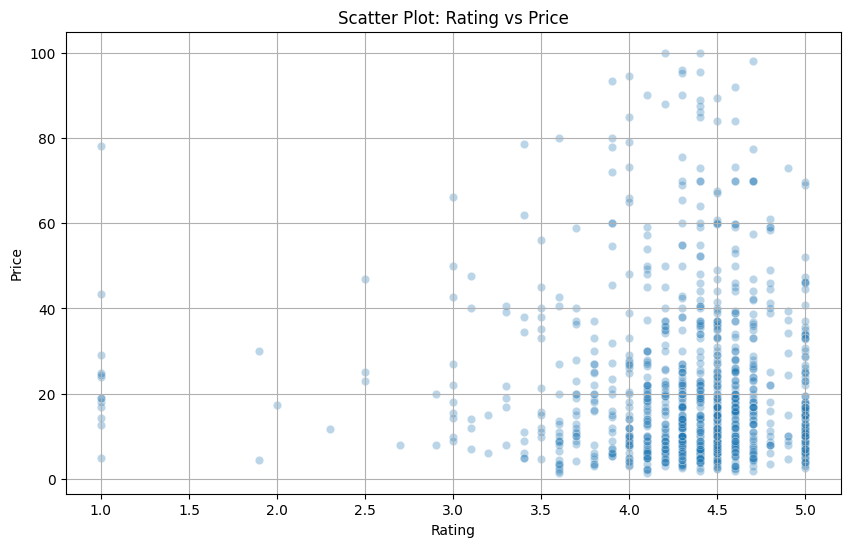

In [ ]:
# Scatter Plot: Price vs Rating

# Filter out rows where the rating is 0 (not rated)
df_cleaned = df_no_outliers[df_no_outliers['stars'] > 0]

# Take a random sample of the data to reduce clutter
df_sampled = df_cleaned.sample(n=1000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sampled, x='stars', y='price', alpha=0.3)
plt.title('Scatter Plot: Rating vs Price')
plt.ylabel('Price')
plt.xlabel('Rating')
plt.grid(True)
plt.show()

# Higher rated products tend to be more expensive, but this relationship is not strong enough to be considered statistically significant, since it also depicts some randomness.

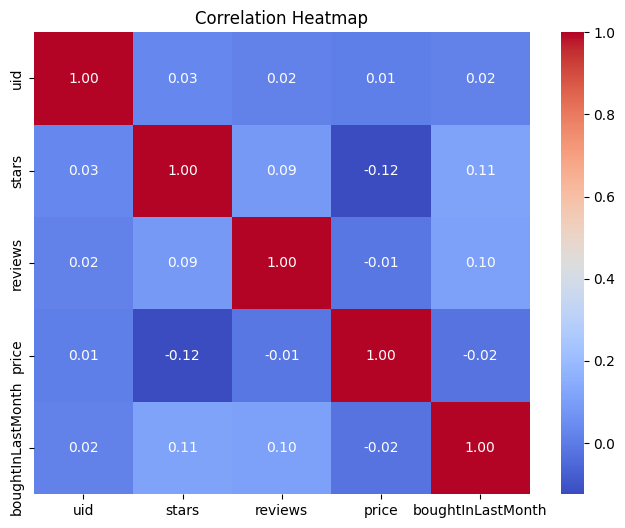

In [29]:
# Correlation Heatmap (Numerical Columns Only)

plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

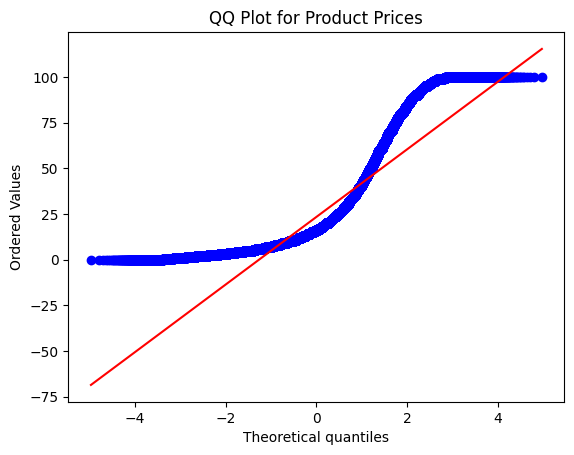

In [ ]:
# QQ Plot to Check Normality of Price Distribution

import scipy.stats as stats

stats.probplot(df_no_outliers['price'], dist="norm", plot=plt)
plt.title("QQ Plot for Product Prices")
plt.show()

# Interpretation: Points deviate significantly from the line, suggesting that the data is not normally distributed → data is skewed or heavy-tailed.